# Text Classification

## 1. Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [58]:
df = pd.read_csv("/content/train.txt", delimiter = ";", header = None, names = ['sentence', 'label' ])

val_df = pd.read_csv("/content/val.txt", delimiter = ";", header = None, names = ['sentence', 'label' ])

ts_df = pd.read_csv("/content/test.txt", delimiter = ";", header = None, names = ['sentence', 'label' ])

In [59]:
df.head()

,sentence,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  16000 non-null  object
 1   label     16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [61]:
# labels name and counts
df['label'].unique()

df.label.value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


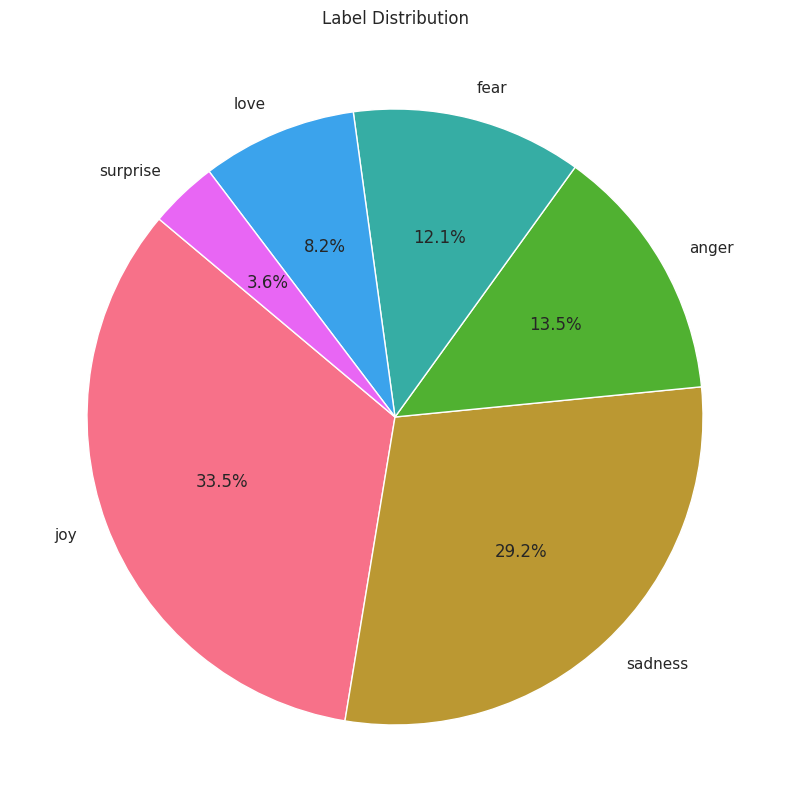

In [62]:
# Label distribuions (Training)
label_counts = df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

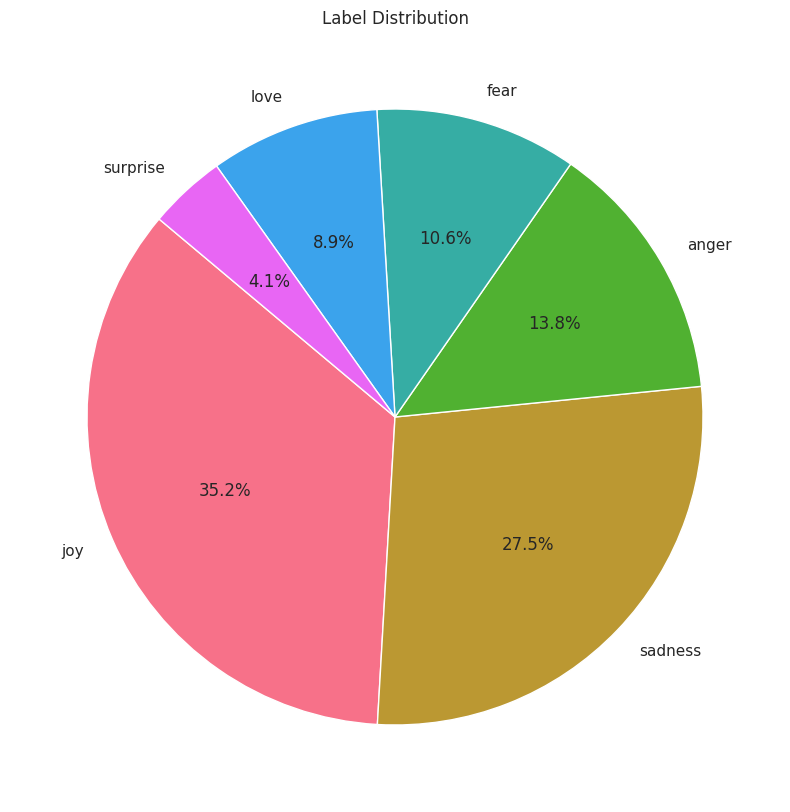

In [63]:
# Label distribuions (Validation)
label_counts = val_df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

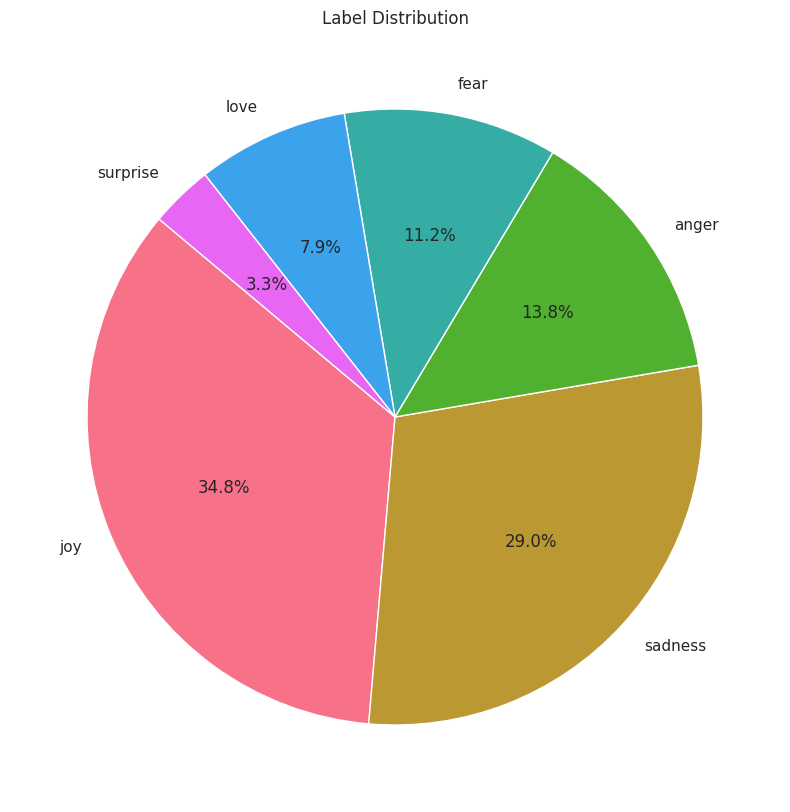

In [64]:
# Label distribuions (Testing)
label_counts = ts_df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

## 3. Handling data distribution

In [65]:
df = df[~df['label'].str.contains('love')]
df = df[~df['label'].str.contains('surprise')]

df.label.unique()

array(['sadness', 'anger', 'fear', 'joy'], dtype=object)

In [66]:
joy = df[df['label'] == 'joy'].sample(n= 2200, random_state = 42)
sad = df[df['label'] == 'sadness'].sample(n= 2200, random_state = 42)
fear = df[df['label'] == 'fear'].sample(n= 1937, random_state = 42)
anger =df[df['label'] == 'anger'].sample(n= 2159, random_state = 42)


df_sampled = pd.concat([joy, sad, fear, anger])

df = df_sampled.sample(frac = 1, random_state=42).reset_index(drop = True)

In [67]:
df.head()

,sentence,label
0,i have control issues though they really only ...,fear
1,i feel so honored to have so much support from...,joy
2,i feel very valued by my patients,joy
3,while cycling in the country,fear
4,i did not feel troubled,sadness


In [68]:
df['label'].value_counts()

,count
label,
joy,2200
sadness,2200
anger,2159
fear,1937


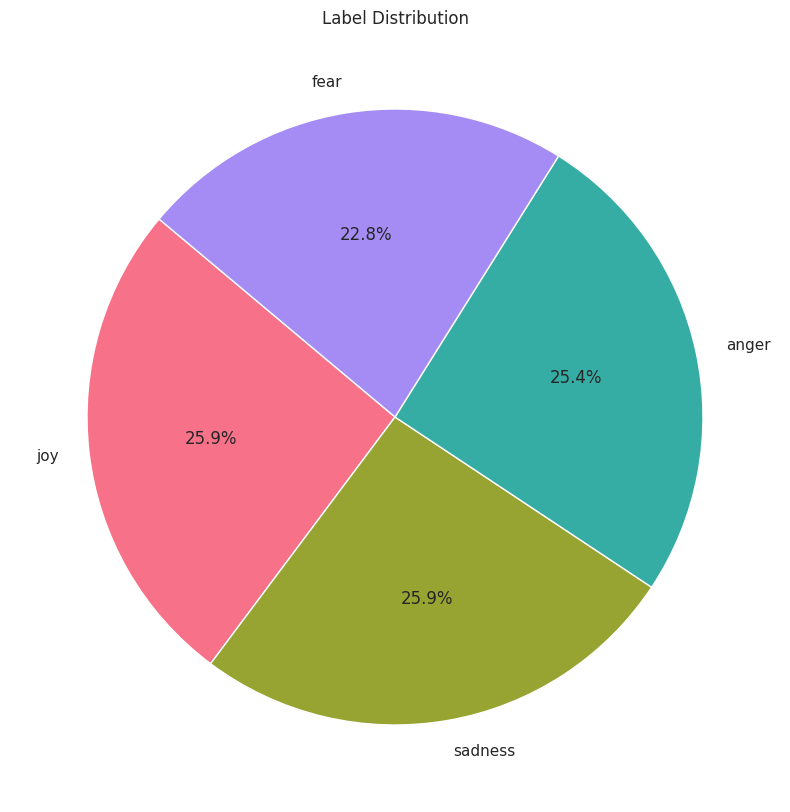

In [69]:
# Label distribuions (Training)
label_counts = df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

In [70]:
val_df = val_df[~df['label'].str.contains('love')]
val_df = val_df[~df['label'].str.contains('surprise')]

/tmp/ipykernel_1278/2569824674.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  val_df = val_df[~df['label'].str.contains('love')]
/tmp/ipykernel_1278/2569824674.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  val_df = val_df[~df['label'].str.contains('surprise')]


In [71]:
joy = val_df[val_df['label'] == 'joy'].sample(n= 250, random_state = 42)
sad = val_df[val_df['label'] == 'sadness'].sample(n= 250, random_state = 42)
fear = val_df[val_df['label'] == 'fear'].sample(n= 212, random_state = 42)
anger =val_df[val_df['label'] == 'anger'].sample(n= 275, random_state = 42)


df_sampled = pd.concat([joy, sad, fear, anger])

val_df = df_sampled.sample(frac = 1, random_state=42).reset_index(drop = True)

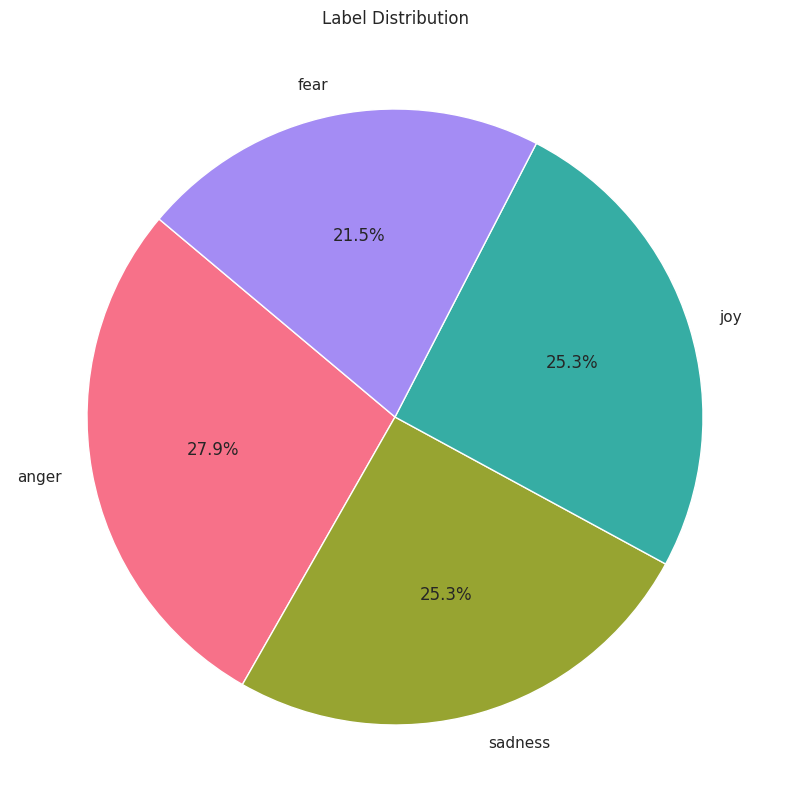

In [72]:
# Label distribuions (Validation)
label_counts = val_df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

In [73]:
ts_df = ts_df[~df['label'].str.contains('love')]
ts_df = ts_df[~df['label'].str.contains('surprise')]

/tmp/ipykernel_1278/683844616.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ts_df = ts_df[~df['label'].str.contains('love')]
/tmp/ipykernel_1278/683844616.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ts_df = ts_df[~df['label'].str.contains('surprise')]


In [74]:
joy = ts_df[ts_df['label'] == 'joy'].sample(n= 250, random_state = 42)
sad = ts_df[ts_df['label'] == 'sadness'].sample(n= 250, random_state = 42)
fear = ts_df[ts_df['label'] == 'fear'].sample(n= 212, random_state = 42)
anger =ts_df[ts_df['label'] == 'anger'].sample(n= 275, random_state = 42)


df_sampled = pd.concat([joy, sad, fear, anger])

ts_df = df_sampled.sample(frac = 1, random_state=42).reset_index(drop = True)

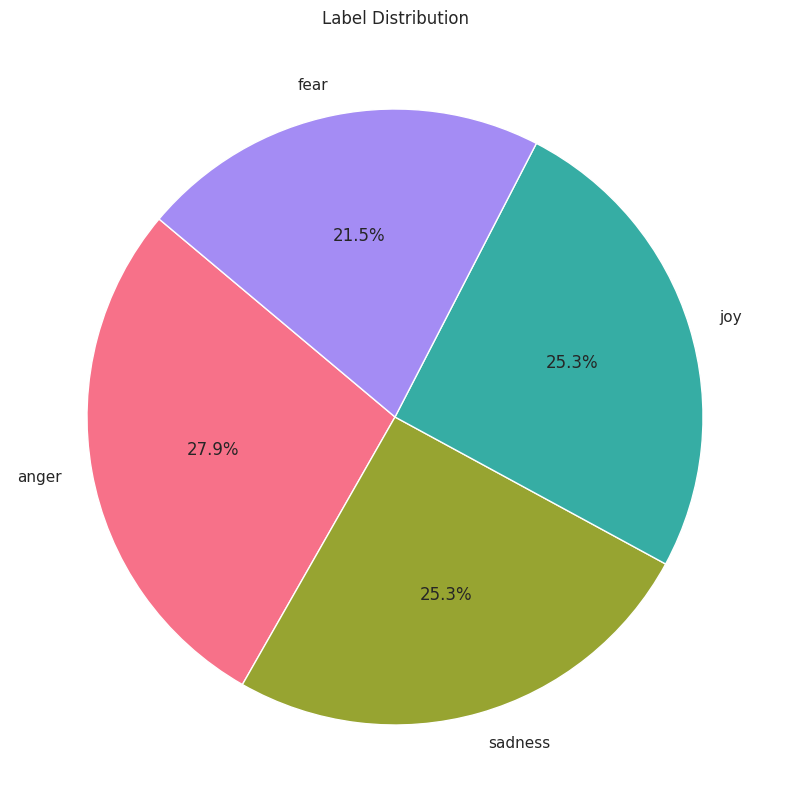

In [75]:
# Label distribuions (Testing)
label_counts = ts_df['label'].value_counts()
ligth_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style = "whitegrid")
plt.figure(figsize=(10, 10))

plt.pie(label_counts, labels = label_counts.index, autopct = '%1.1f%%', startangle = 140, colors = ligth_colors)

plt.title('Label Distribution')
plt.show()

In [76]:
tr_text = df['sentence']
tr_label = df['label']

val_text = val_df['sentence']
val_label = val_df['label']

ts_text = ts_df['sentence']
ts_label = ts_df['label']

## 4. Encoding Processing

In [77]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

tr_label = le.fit_transform(tr_label)
val_label = le.transform(val_label)
ts_label = le.transform(ts_label)

In [78]:
tr_label

array([1, 2, 2, ..., 1, 2, 0])

## 5 Tokanizer Building

In [79]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk import tokenize
from tensorflow.keras.utils import to_categorical

In [80]:
# Initializing Input vector
class_vector =[2, 5, 6, 1, 4, 2, 3, 2]
print(class_vector)

output_matrix = to_categorical(class_vector, num_classes = 7)

print(output_matrix)

[2, 5, 6, 1, 4, 2, 3, 2]
[[0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]


In [81]:
tokenizer = Tokenizer(num_words= 10000)

tokenizer.fit_on_texts(tr_text)

tr_x = pad_sequences(tokenizer.texts_to_sequences(tr_text), padding = 'post', )
tr_y = to_categorical(tr_label)


val_x = pad_sequences(tokenizer.texts_to_sequences(val_text), padding = 'post')
val_y = to_categorical(val_label)

ts_x = pad_sequences(tokenizer.texts_to_sequences(ts_text), padding = 'post')
ts_y = to_categorical(ts_label)

In [82]:
tokenizer.word_index

len(tokenizer.word_counts)

10705

## 6. Embedding and Model Arch

In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision


In [84]:
vocab_size = 10628
embedding_dim = 128
input_length = 100
num_classes = 4

In [89]:
# Build the LSTM model with enhanced architecture
model = Sequential([
    # Embedding layer to convert words into dense vectors
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),

    # Bidirectional LSTM layer to capture context from both directions
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),  # Dropout to reduce overfitting

    # Global Max Pooling to reduce sequence length and capture key features
    GlobalMaxPooling1D(),

    # Dense layer with regularization to learn complex representations
    Dense(64, activation='relu'),
    Dropout(0.5),  # Dropout to further reduce overfitting

    # Output layer with softmax activation for multi-class classification
    Dense(num_classes, activation='softmax')
])

model.build(input_shape=(None, input_length))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [91]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Recall(), Precision()])

In [92]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,360,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,467,716 (5.60 MB)

 Trainable params: 1,467,716 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
# prevent from overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(tr_x, tr_y, validation_data=(val_x, val_y), epochs=20, batch_size=32, callbacks=[early_stopping])

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 30s 93ms/step - accuracy: 0.5250 - loss: 1.0453 - precision_3: 0.8902 - recall_3: 0.2720 - val_accuracy: 0.9321 - val_loss: 0.3334 - val_precision_3: 0.9630 - val_recall_3: 0.8977
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 90ms/step - accuracy: 0.9433 - loss: 0.1959 - precision_3: 0.9507 - recall_3: 0.9356 - val_accuracy: 0.9443 - val_loss: 0.2021 - val_precision_3: 0.9619 - val_recall_3: 0.9220
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step - accuracy: 0.9767 - loss: 0.0875 - precision_3: 0.9788 - recall_3: 0.9732 - val_accuracy: 0.9493 - val_loss: 0.1538 - val_precision_3: 0.9564 - val_recall_3: 0.9341
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9829 - loss: 0.0599 - precision_3: 0.9842 - recall_3: 0.9818 - val_accuracy: 0.9422 - val_loss: 0.1481 - val_precision_3: 0.9574 - val_recall_3: 0.9331
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.9885 - loss: 0.0436 - precision_3: 0.9893 - recall_3

In [95]:
# Evaluation the model test
test_loss, test_accuracy, test_recall, test_precision = model.evaluate(ts_x, ts_y)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test Recall: {test_recall:.4f}, Test Precision: {test_precision:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9412 - loss: 0.1502 - precision_3: 0.9507 - recall_3: 0.9372
Test Loss: 0.1502, Test Accuracy: 0.9412, Test Recall: 0.9372, Test Precision: 0.9507


In [101]:
y_true = []

for i in range(len(ts_y)):
  x = np.argmax(ts_y[i])
  y_true.append(x)

In [97]:
preds = model.predict(ts_x)
y_pred = np.argmax(preds, axis=1)
y_pred

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


array([3, 2, 3, 0, 2, 3, 0, 2, 2, 1, 2, 2, 2, 2, 1, 3, 0, 3, 2, 2, 0, 3,
       1, 3, 0, 3, 1, 0, 0, 0, 0, 3, 1, 1, 1, 3, 3, 0, 0, 3, 3, 2, 2, 0,
       2, 2, 1, 2, 3, 0, 0, 1, 2, 0, 3, 0, 1, 2, 0, 3, 2, 3, 0, 3, 3, 2,
       3, 1, 3, 2, 0, 2, 1, 3, 0, 1, 0, 1, 3, 0, 3, 0, 2, 0, 0, 1, 3, 0,
       3, 2, 1, 3, 2, 1, 0, 1, 2, 3, 0, 3, 1, 3, 1, 2, 3, 1, 2, 3, 3, 3,
       0, 0, 2, 0, 0, 1, 2, 1, 3, 2, 2, 2, 2, 1, 2, 1, 3, 3, 1, 3, 3, 2,
       2, 3, 1, 2, 2, 0, 0, 1, 1, 2, 3, 1, 3, 1, 1, 3, 0, 3, 1, 2, 3, 0,
       2, 2, 1, 3, 0, 3, 3, 3, 0, 1, 3, 1, 3, 0, 1, 0, 0, 0, 1, 0, 0, 2,
       3, 0, 2, 2, 0, 0, 3, 1, 2, 3, 3, 3, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3,
       0, 0, 2, 0, 3, 1, 3, 0, 1, 3, 0, 2, 0, 2, 2, 0, 2, 3, 1, 0, 3, 1,
       2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 0, 3, 1, 3, 2, 2, 3, 3, 3, 2, 3, 2,
       2, 0, 0, 0, 1, 1, 2, 1, 2, 3, 1, 0, 2, 1, 0, 0, 0, 3, 1, 1, 2, 3,
       3, 1, 2, 2, 1, 2, 3, 3, 0, 2, 3, 2, 0, 0, 3, 1, 0, 3, 0, 1, 0, 3,
       0, 3, 0, 2, 2, 1, 0, 3, 2, 0, 0, 3, 1, 0, 1,

<Axes: >

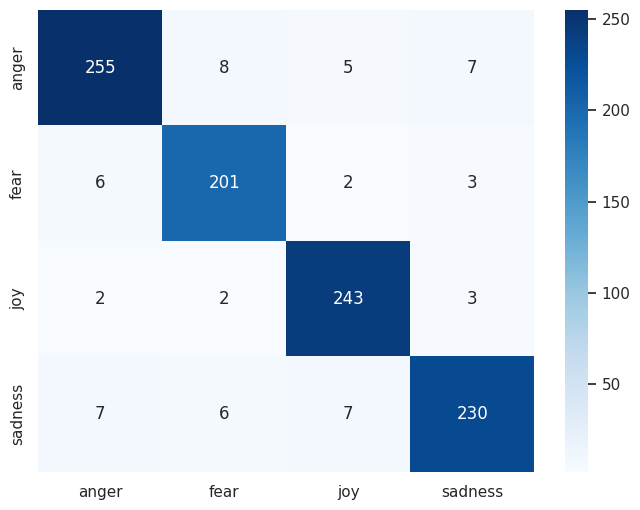

In [103]:
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(8,6))
emotions = {0: 'anger', 1: 'fear', 2: 'joy', 3:'sadness'}
emotions = list(emotions.values())
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)

In [104]:
import pickle
with open('tokenizer.pkl', 'wb') as tokenizer_file:
    pickle.dump(tokenizer, tokenizer_file)

model.save('nlp.h5')


## 7. Model Testing

In [105]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import load_model

In [106]:
def predict(text, model_path, token_path):

    model = load_model(model_path)


    with open(token_path, 'rb') as f:
        tokenizer = pickle.load(f)

    sequences = tokenizer.texts_to_sequences([text])
    x_new = pad_sequences(sequences, maxlen=100)
    predictions = model.predict(x_new)

    return predictions

In [107]:
# example - 1
txt = 'I am pleased to say it was a wonderful project'
predict(txt, 'nlp.h5', 'tokenizer.pkl')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


array([[0.0109309 , 0.00984852, 0.96716654, 0.01205403]], dtype=float32)

In [109]:
def predict(text, model_path, token_path):

    model = load_model(model_path)


    with open(token_path, 'rb') as f:
        tokenizer = pickle.load(f)

    sequences = tokenizer.texts_to_sequences([text])
    x_new = pad_sequences(sequences, maxlen=100)
    predictions = model.predict(x_new)

    emotions = {0: 'anger', 1: 'fear', 2: 'joy', 3:'sadness'}

    label = list(emotions.values())
    probs = list(predictions[0])

    labels = label

    plt.subplot(1, 1, 1)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step


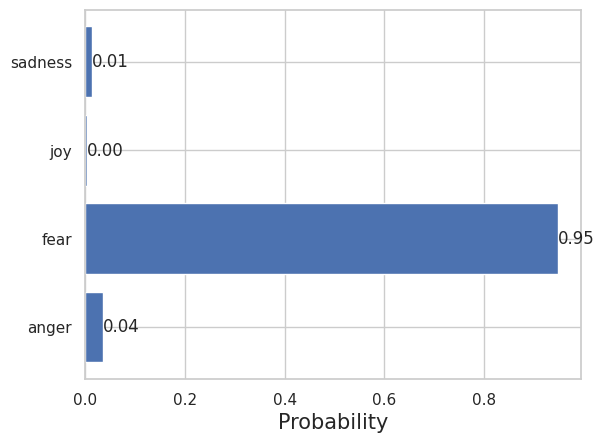

In [113]:
# example - 2
txt = 'I am afraid from her because she told me leave the office asap'
predict(txt, 'nlp.h5', 'tokenizer.pkl')